# STAT 790 — Comparing anomaly detection methods (with an application to Healthcare) - Unsupervised

**Francesco Pecora**

This notebook builds the modeling pipeline for the Medicare Provider Fraud Detection project.

## Modeling philosophy
We train each model using only providers confirmed as legitimate, without exposing any fraud labels during training. Once trained, each model scores all 5,410 providers by how unusual their behavior appears relative to the learned baseline of normal activity. Fraud labels are then used exclusively to measure how well those anomaly scores separate fraudulent providers from legitimate ones. The working unit for modeling is the provider, because fraud in this dataset manifests as a persistent pattern of unusual billing behavior across many claims rather than any single anomalous transaction.

# 0. Setup
**What we're doing:** Loading all the Python libraries we'll need throughout the notebook. Setting a random seed so results are reproducible — meaning if you or anyone else runs this notebook again, the models will produce the exact same numbers.

**Goal:** Make sure every tool is ready and the environment is consistent.

In [26]:

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix
)

# Optional deep learning imports
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Libraries loaded.")

Libraries loaded.


## 1. Download / load the dataset from Kaggle

**What we're doing:** Pulling the Medicare fraud dataset directly from Kaggle. The output confirms eight CSV files are available — four for training, four for testing. We only use the training files.

**Goal:** Get the raw data into the environment without manual file uploads.

In [27]:
# =========================
# 1. Download dataset from Kaggle
# =========================
# If you already have kagglehub installed in Colab, this is safe to rerun.
!pip install kagglehub --quiet

import kagglehub

path = kagglehub.dataset_download("rohitrox/healthcare-provider-fraud-detection-analysis")
print("Downloaded to:", path)

for f in sorted(os.listdir(path)):
    print(" -", f)

BASE = path + "/"
PATH_LABELS     = BASE + "Train-1542865627584.csv"
PATH_BENE       = BASE + "Train_Beneficiarydata-1542865627584.csv"
PATH_INPATIENT  = BASE + "Train_Inpatientdata-1542865627584.csv"
PATH_OUTPATIENT = BASE + "Train_Outpatientdata-1542865627584.csv"

print("\nPaths set.")

Using Colab cache for faster access to the 'healthcare-provider-fraud-detection-analysis' dataset.
Downloaded to: /kaggle/input/healthcare-provider-fraud-detection-analysis
 - Test-1542969243754.csv
 - Test_Beneficiarydata-1542969243754.csv
 - Test_Inpatientdata-1542969243754.csv
 - Test_Outpatientdata-1542969243754.csv
 - Train-1542865627584.csv
 - Train_Beneficiarydata-1542865627584.csv
 - Train_Inpatientdata-1542865627584.csv
 - Train_Outpatientdata-1542865627584.csv

Paths set.


## 2. Load and merge the four files

**What we're doing:** Reading the four training files separately. We have 5,410 provider labels, 138,556 patient records, 40,474 inpatient claims, and 517,737 outpatient claims. We then stack inpatient and outpatient claims into one table, join patient demographics onto each claim by patient ID, and join the fraud label onto each claim by provider ID. We also calculate length of stay for inpatient claims by subtracting admission date from discharge date.

**Goal:** Create a single unified table where every row is one claim and already knows whether that claim's provider is fraudulent or not.

In [28]:
# =========================
# 2. Load source files
# =========================
df_labels = pd.read_csv(PATH_LABELS)
df_bene   = pd.read_csv(PATH_BENE)
df_inp    = pd.read_csv(PATH_INPATIENT)
df_out    = pd.read_csv(PATH_OUTPATIENT)

print("Labels shape:      ", df_labels.shape)
print("Beneficiary shape: ", df_bene.shape)
print("Inpatient shape:   ", df_inp.shape)
print("Outpatient shape:  ", df_out.shape)

Labels shape:       (5410, 2)
Beneficiary shape:  (138556, 25)
Inpatient shape:    (40474, 30)
Outpatient shape:   (517737, 27)


In [29]:
# =========================
# 3. Claim-level assembly
# =========================
df_inp["ClaimType"] = "Inpatient"
df_out["ClaimType"] = "Outpatient"

# Parse dates
date_cols_inp = ["ClaimStartDt", "ClaimEndDt", "AdmissionDt", "DischargeDt"]
date_cols_out = ["ClaimStartDt", "ClaimEndDt"]
date_cols_bene = ["DOB", "DOD"]

for c in date_cols_inp:
    if c in df_inp.columns:
        df_inp[c] = pd.to_datetime(df_inp[c], errors="coerce")

for c in date_cols_out:
    if c in df_out.columns:
        df_out[c] = pd.to_datetime(df_out[c], errors="coerce")

for c in date_cols_bene:
    if c in df_bene.columns:
        df_bene[c] = pd.to_datetime(df_bene[c], errors="coerce")

# Inpatient-only engineered field
if {"AdmissionDt", "DischargeDt"}.issubset(df_inp.columns):
    df_inp["LengthOfStay"] = (df_inp["DischargeDt"] - df_inp["AdmissionDt"]).dt.days

# Concatenate claims
df_claims = pd.concat([df_inp, df_out], axis=0, ignore_index=True)

# Join beneficiary data
df_claims = df_claims.merge(df_bene, on="BeneID", how="left")

# Join fraud labels
df_claims = df_claims.merge(df_labels, on="Provider", how="left")
df_claims["IsFraud"] = (df_claims["PotentialFraud"] == "Yes").astype(int)

# Create a unified claim date and month
date_candidates = ["ClaimStartDt", "AdmissionDt"]
date_col = next((c for c in date_candidates if c in df_claims.columns), None)

if date_col is not None:
    df_claims["ClaimDate"] = pd.to_datetime(df_claims[date_col], errors="coerce")
    df_claims["YearMonth"] = df_claims["ClaimDate"].dt.to_period("M").astype(str)

print("Combined claim-level dataset shape:", df_claims.shape)
print("Claim-level fraud rate:", f"{df_claims['IsFraud'].mean():.2%}")
df_claims.head()

Combined claim-level dataset shape: (558211, 60)
Claim-level fraud rate: 38.12%


,BeneID,ClaimID,ClaimStartDt,ClaimEndDt,Provider,InscClaimAmtReimbursed,AttendingPhysician,OperatingPhysician,OtherPhysician,AdmissionDt,...,ChronicCond_rheumatoidarthritis,ChronicCond_stroke,IPAnnualReimbursementAmt,IPAnnualDeductibleAmt,OPAnnualReimbursementAmt,OPAnnualDeductibleAmt,PotentialFraud,IsFraud,ClaimDate,YearMonth
0,BENE11001,CLM46614,2009-04-12,2009-04-18,PRV55912,26000,PHY390922,NaN,NaN,2009-04-12,...,1,1,36000,3204,60,70,Yes,1,2009-04-12,2009-04
1,BENE11001,CLM66048,2009-08-31,2009-09-02,PRV55907,5000,PHY318495,PHY318495,NaN,2009-08-31,...,1,1,36000,3204,60,70,No,0,2009-08-31,2009-08
2,BENE11001,CLM68358,2009-09-17,2009-09-20,PRV56046,5000,PHY372395,NaN,PHY324689,2009-09-17,...,1,1,36000,3204,60,70,No,0,2009-09-17,2009-09
3,BENE11011,CLM38412,2009-02-14,2009-02-22,PRV52405,5000,PHY369659,PHY392961,PHY349768,2009-02-14,...,1,1,5000,1068,250,320,No,0,2009-02-14,2009-02
4,BENE11014,CLM63689,2009-08-13,2009-08-30,PRV56614,10000,PHY379376,PHY398258,NaN,2009-08-13,...,2,2,21260,2136,120,100,No,0,2009-08-13,2009-08


**What the results tell us:** The combined dataset has 558,211 claims and 60 columns. The claim-level fraud rate is 38.12% — meaning 38% of all claims in this dataset were filed by providers who are labeled fraudulent. This is higher than you might expect and reflects the fact that fraudulent providers tend to file large volumes of claims, so even though only 9.4% of providers are fraudulent, their claims represent a disproportionately large share of the total.

## 3. Feature engineering at the provider level

**What we're doing:** This is the most important data preparation step. Since fraud is labeled at the provider level, not the claim level, we need to summarize each provider's behavior into a single row. We compress 558,211 claim rows into 5,410 provider rows by computing statistics for each provider across all their claims.
The features fall into five groups:

- Billing behavior: total claims, total reimbursed, average/median/max/std reimbursement, deductible stats
- Diagnosis patterns: how many unique diagnosis codes, what fraction of claims
use the single most common code (concentration), how spread out the codes are (entropy)
- Physician network: how many unique attending physicians, claims per physician, inpatient vs outpatient share
- Patient demographics: average patient age, female share, renal disease share
- Chronic condition burden: average prevalence of 10 chronic conditions across the provider's patients
- Temporal behavior: months active, how much billing amounts fluctuate month to month (volatility), the largest single-month jump

**Goal:** Turn raw claims data into a meaningful behavioral fingerprint for each provider — one that captures the patterns the EDA showed were different between fraudulent and legitimate providers.

In [30]:
# =========================
# 4. Helper utilities
# =========================
def safe_divide(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

def top_code_concentration(series):
    counts = series.dropna().value_counts()
    if len(counts) == 0:
        return np.nan
    return counts.iloc[0] / counts.sum()

def normalized_entropy(series):
    counts = series.dropna().value_counts(normalize=True)
    if len(counts) <= 1:
        return 0.0
    ent = stats.entropy(counts)
    max_ent = np.log(len(counts))
    return ent / max_ent if max_ent > 0 else 0.0

In [31]:
# =========================
# 5. Provider-level aggregation
# =========================
provider_agg = df_claims.groupby("Provider").agg(
    TotalClaims=("ClaimID", "count"),
    TotalReimbursed=("InscClaimAmtReimbursed", "sum"),
    AvgReimbursed=("InscClaimAmtReimbursed", "mean"),
    MedianReimbursed=("InscClaimAmtReimbursed", "median"),
    MaxReimbursed=("InscClaimAmtReimbursed", "max"),
    StdReimbursed=("InscClaimAmtReimbursed", "std"),
    AvgDeductible=("DeductibleAmtPaid", "mean"),
    MaxDeductible=("DeductibleAmtPaid", "max"),
    UniquePatients=("BeneID", "nunique"),
    UniqueDiagnosisCodes=("ClmDiagnosisCode_1", "nunique"),
    UniqueStates=("State", "nunique"),
    UniqueCounties=("County", "nunique"),
    FraudLabel=("IsFraud", "first")
).reset_index()

provider_agg["ClaimsPerPatient"] = safe_divide(
    provider_agg["TotalClaims"], provider_agg["UniquePatients"]
)

provider_agg["DiagnosisConcentration"] = (
    df_claims.groupby("Provider")["ClmDiagnosisCode_1"]
    .apply(top_code_concentration)
    .reindex(provider_agg["Provider"])
    .values
)

provider_agg["DiagnosisEntropy"] = (
    df_claims.groupby("Provider")["ClmDiagnosisCode_1"]
    .apply(normalized_entropy)
    .reindex(provider_agg["Provider"])
    .values
)

# Inpatient share
inp_share = (
    df_claims.assign(IsInpatient=(df_claims["ClaimType"] == "Inpatient").astype(int))
    .groupby("Provider")["IsInpatient"]
    .mean()
)

provider_agg["InpatientShare"] = provider_agg["Provider"].map(inp_share)

# Length of stay features
if "LengthOfStay" in df_claims.columns:
    los_stats = df_claims.groupby("Provider")["LengthOfStay"].agg(
        AvgLengthOfStay="mean",
        MaxLengthOfStay="max",
        StdLengthOfStay="std"
    )
    provider_agg = provider_agg.merge(
        los_stats, left_on="Provider", right_index=True, how="left"
    )

# Physician network features
if "AttendingPhysician" in df_claims.columns:
    physician_stats = df_claims.groupby("Provider").agg(
        UniquePhysicians=("AttendingPhysician", "nunique")
    )
    provider_agg = provider_agg.merge(
        physician_stats, left_on="Provider", right_index=True, how="left"
    )
    provider_agg["ClaimsPerPhysician"] = safe_divide(
        provider_agg["TotalClaims"], provider_agg["UniquePhysicians"]
    )

# Beneficiary demographics at provider level
demo_stats = df_claims.groupby("Provider").agg(
    AvgAge=("DOB", lambda s: np.nan if s.isna().all() else
            (pd.Timestamp("2009-12-31") - s).dt.days.mean() / 365.25),
    FemaleShare=("Gender", lambda s: np.mean(s == 2) if len(s.dropna()) else np.nan),
    RenalShare=("RenalDiseaseIndicator", lambda s: np.mean(s.astype(str) == "Y") if len(s.dropna()) else np.nan)
)
provider_agg = provider_agg.merge(
    demo_stats, left_on="Provider", right_index=True, how="left"
)

# Chronic condition burden
chronic_cols = [c for c in df_claims.columns if c.startswith("ChronicCond_")]
if chronic_cols:
    chronic_provider = df_claims.groupby("Provider")[chronic_cols].agg(
        lambda s: pd.to_numeric(s, errors="coerce").mean()
    )
    chronic_provider.columns = [f"{c}_Mean" for c in chronic_provider.columns]
    provider_agg = provider_agg.merge(
        chronic_provider, left_on="Provider", right_index=True, how="left"
    )

print("Provider-level dataset shape:", provider_agg.shape)
provider_agg.head()

Provider-level dataset shape: (5410, 37)


,Provider,TotalClaims,TotalReimbursed,AvgReimbursed,MedianReimbursed,MaxReimbursed,StdReimbursed,AvgDeductible,MaxDeductible,UniquePatients,...,ChronicCond_Heartfailure_Mean,ChronicCond_KidneyDisease_Mean,ChronicCond_Cancer_Mean,ChronicCond_ObstrPulmonary_Mean,ChronicCond_Depression_Mean,ChronicCond_Diabetes_Mean,ChronicCond_IschemicHeart_Mean,ChronicCond_Osteoporasis_Mean,ChronicCond_rheumatoidarthritis_Mean,ChronicCond_stroke_Mean
0,PRV51001,25,104640,4185.600000,400.0,42000,10796.091144,213.600000,1068.0,24,...,1.240000,1.320000,1.800000,1.600000,1.640000,1.160000,1.080000,1.760000,1.680000,1.760000
1,PRV51003,132,605670,4588.409091,1750.0,57000,7309.794729,502.166667,1068.0,117,...,1.393939,1.515152,1.924242,1.689394,1.590909,1.242424,1.151515,1.750000,1.712121,1.909091
2,PRV51004,149,52170,350.134228,70.0,3300,689.963754,2.080537,100.0,138,...,1.409396,1.664430,1.892617,1.724832,1.577181,1.295302,1.275168,1.671141,1.691275,1.885906
3,PRV51005,1165,280910,241.124464,70.0,4080,491.556392,3.175966,200.0,495,...,1.416309,1.564807,1.858369,1.746781,1.583691,1.314163,1.231760,1.704721,1.715880,1.893562
4,PRV51007,72,33710,468.194444,80.0,10000,1433.769116,45.333333,1068.0,58,...,1.444444,1.694444,1.833333,1.777778,1.597222,1.319444,1.291667,1.708333,1.694444,1.833333


In [32]:
# =========================
# 6. Temporal behavior features
# =========================
if "YearMonth" in df_claims.columns:
    monthly = (
        df_claims.groupby(["Provider", "YearMonth"])
        .agg(
            MonthlyAvgReimbursed=("InscClaimAmtReimbursed", "mean"),
            MonthlyTotalReimbursed=("InscClaimAmtReimbursed", "sum"),
            MonthlyClaims=("ClaimID", "count")
        )
        .reset_index()
        .sort_values(["Provider", "YearMonth"])
    )

    for col in ["MonthlyAvgReimbursed", "MonthlyTotalReimbursed", "MonthlyClaims"]:
        monthly[f"{col}_PctChange"] = (
            monthly.groupby("Provider")[col].pct_change()
        )

    temporal = monthly.groupby("Provider").agg(
        MonthsActive=("YearMonth", "count"),
        BillingVolatility=("MonthlyAvgReimbursed_PctChange", "std"),
        MaxSingleJump=("MonthlyAvgReimbursed_PctChange", lambda x: np.nanmax(np.abs(x)) if len(x.dropna()) else np.nan),
        ClaimsVolatility=("MonthlyClaims_PctChange", "std"),
        TotalReimbursedVolatility=("MonthlyTotalReimbursed_PctChange", "std")
    )

    provider_agg = provider_agg.merge(
        temporal, left_on="Provider", right_index=True, how="left"
    )

provider_agg.head()

,Provider,TotalClaims,TotalReimbursed,AvgReimbursed,MedianReimbursed,MaxReimbursed,StdReimbursed,AvgDeductible,MaxDeductible,UniquePatients,...,ChronicCond_Diabetes_Mean,ChronicCond_IschemicHeart_Mean,ChronicCond_Osteoporasis_Mean,ChronicCond_rheumatoidarthritis_Mean,ChronicCond_stroke_Mean,MonthsActive,BillingVolatility,MaxSingleJump,ClaimsVolatility,TotalReimbursedVolatility
0,PRV51001,25,104640,4185.600000,400.0,42000,10796.091144,213.600000,1068.0,24,...,1.160000,1.080000,1.760000,1.680000,1.760000,10,29.888867,90.703390,0.760746,21.381329
1,PRV51003,132,605670,4588.409091,1750.0,57000,7309.794729,502.166667,1068.0,117,...,1.242424,1.151515,1.750000,1.712121,1.909091,13,0.733322,1.957423,3.487988,4.469106
2,PRV51004,149,52170,350.134228,70.0,3300,689.963754,2.080537,100.0,138,...,1.295302,1.275168,1.671141,1.691275,1.885906,12,2.846306,7.750000,0.434752,5.278802
3,PRV51005,1165,280910,241.124464,70.0,4080,491.556392,3.175966,200.0,495,...,1.314163,1.231760,1.704721,1.715880,1.893562,13,0.279288,0.509804,14.436726,21.927279
4,PRV51007,72,33710,468.194444,80.0,10000,1433.769116,45.333333,1068.0,58,...,1.319444,1.291667,1.708333,1.694444,1.833333,12,2.720426,6.307143,0.874076,4.191719


**What the results tell us:** The provider-level dataset has 5,410 rows and 37 columns after this step, later expanded to 40 after temporal features are added. The feature names visible in the output — TotalClaims, TotalReimbursed, DiagnosisConcentration, BillingVolatility, ChronicCond means — confirm all five feature groups are correctly computed.

## 4. Final modeling matrix

**What we're doing:** Selecting only numeric columns for modeling, explicitly excluding the provider ID and the fraud label. The label is kept separate and used only for evaluation later. We then check for missing values and handle them.

**Goal:** Produce a clean matrix X (features) and vector y (labels) where X has no fraud information in it at all. This enforces the unsupervised learning contract.

In [33]:
# =========================
# 7. Final feature list
# =========================
excluded_cols = ["Provider", "FraudLabel"]
feature_cols = [c for c in provider_agg.columns if c not in excluded_cols]

# Keep numeric features only
numeric_feature_cols = []
for c in feature_cols:
    if pd.api.types.is_numeric_dtype(provider_agg[c]):
        numeric_feature_cols.append(c)

X_df = provider_agg[numeric_feature_cols].copy()
y = provider_agg["FraudLabel"].astype(int).values

print("Number of providers:", len(provider_agg))
print("Fraudulent providers:", int(provider_agg["FraudLabel"].sum()))
print("Feature count:", len(numeric_feature_cols))
print("\nFeatures:")
print(numeric_feature_cols)

Number of providers: 5410
Fraudulent providers: 506
Feature count: 40

Features:
['TotalClaims', 'TotalReimbursed', 'AvgReimbursed', 'MedianReimbursed', 'MaxReimbursed', 'StdReimbursed', 'AvgDeductible', 'MaxDeductible', 'UniquePatients', 'UniqueDiagnosisCodes', 'UniqueStates', 'UniqueCounties', 'ClaimsPerPatient', 'DiagnosisConcentration', 'DiagnosisEntropy', 'InpatientShare', 'AvgLengthOfStay', 'MaxLengthOfStay', 'StdLengthOfStay', 'UniquePhysicians', 'ClaimsPerPhysician', 'AvgAge', 'FemaleShare', 'RenalShare', 'ChronicCond_Alzheimer_Mean', 'ChronicCond_Heartfailure_Mean', 'ChronicCond_KidneyDisease_Mean', 'ChronicCond_Cancer_Mean', 'ChronicCond_ObstrPulmonary_Mean', 'ChronicCond_Depression_Mean', 'ChronicCond_Diabetes_Mean', 'ChronicCond_IschemicHeart_Mean', 'ChronicCond_Osteoporasis_Mean', 'ChronicCond_rheumatoidarthritis_Mean', 'ChronicCond_stroke_Mean', 'MonthsActive', 'BillingVolatility', 'MaxSingleJump', 'ClaimsVolatility', 'TotalReimbursedVolatility']


In [34]:
# Quick missingness inspection
missing = X_df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing):
    display(missing.to_frame("missing_rate").head(20))
else:
    print("No missing values in numeric modeling features.")

,missing_rate
StdLengthOfStay,0.653050
AvgLengthOfStay,0.613309
MaxLengthOfStay,0.613309
BillingVolatility,0.143068
TotalReimbursedVolatility,0.143068
ClaimsVolatility,0.087800
MaxSingleJump,0.047135
StdReimbursed,0.044362
DiagnosisConcentration,0.000924
AvgDeductible,0.000185


In [35]:
# =========================
# 8. Preprocessing
# =========================
# Replace +/- inf before imputation
X_df = X_df.replace([np.inf, -np.inf], np.nan)

# Optional sanity check
bad_cols = []
for c in X_df.columns:
    vals = pd.to_numeric(X_df[c], errors="coerce")
    if np.isinf(vals).any():
        bad_cols.append(c)

if bad_cols:
    print("Columns still containing inf:", bad_cols)
else:
    print("No infinite values remain in X_df.")

preprocessor = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X = preprocessor.fit_transform(X_df)

print("Processed matrix shape:", X.shape)

No infinite values remain in X_df.
Processed matrix shape: (5410, 40)


**What the results tell us:** We end up with 40 features. The missing value report shows that length-of-stay features are missing for about 61-65% of providers — which makes sense because most providers are outpatient-only and have no admission/discharge dates. BillingVolatility is missing for about 14% of providers who have fewer than two months of data. All of these are imputed using median values in the next step, which is appropriate.

## 5. Train/test philosophy for unsupervised evaluation

**What we're doing:** Splitting all 5,410 providers into a 70% training set and a 30% held-out test set, stratified by fraud label so both sets preserve the natural 9.4% fraud rate. The training set contains both legitimate and fraudulent providers (mirroring real deployment, where you can't pre-filter out fraud). Distance and tree-based methods (Isolation Forest, LOF) train on the full training set and use the contamination parameter to set their internal threshold. Reconstruction-based methods (Autoencoder, VAE) train only on the legitimate portion of the training set — the natural semi-supervised pattern for these models. All evaluation is on the held-out test set, which neither model has seen. This is methodologically equivalent to the supervised notebook (same SEED, same test_size, same stratify), so test-set comparisons are direct and per-provider.

In [36]:
# =========================
# 9. Stratified train/test split — matches supervised notebook exactly
# =========================
from sklearn.model_selection import train_test_split

# Get indices first so we can map test predictions back to provider_agg rows later
idx_all = np.arange(len(y))
idx_train, idx_test = train_test_split(
    idx_all, test_size=0.30, stratify=y, random_state=SEED
)

X_train_full, X_test = X[idx_train], X[idx_test]
y_train_full, y_test = y[idx_train], y[idx_test]

fraud_rate = y_train_full.mean()
X_train_normal = X_train_full[y_train_full == 0]

print(f'Train (full):    {len(y_train_full)} providers  ({y_train_full.sum()} fraud, {fraud_rate:.1%})')
print(f'Train (normal):  {len(X_train_normal)} providers  (legitimate only — for AE/VAE)')
print(f'Test (held-out): {len(y_test)} providers  ({y_test.sum()} fraud, {y_test.mean():.1%})')

Train (full):    3787 providers  (354 fraud, 9.3%)
Train (normal):  3433 providers  (legitimate only — for AE/VAE)
Test (held-out): 1623 providers  (152 fraud, 9.4%)


**What the results tell us:** The stratified 70/30 split produces 3,787 training providers (354 fraud, 9.3%) and 1,623 test providers (152 fraud, 9.4%). For Isolation Forest and LOF, the full training set (with fraud mixed in) is used along with the contamination parameter. For the Autoencoder and VAE, only the 3,433 legitimate providers in the training set are used for reconstruction learning. All metrics reported below are computed on the held-out test set, which neither model has seen during training.

## 6. Evaluation helpers
**What we're doing:** Defining three functions that all models will use. The first converts raw anomaly scores to a 0-to-1 ranking so all models are comparable on the same scale. The second takes a top-fraction threshold (flag the top 5% or top 10% of suspicious providers) and computes precision, recall, F1, ROC-AUC and PR-AUC. The third calculates financial impact by looking up how much money the correctly flagged providers received.

**Goal:** Create a consistent, fair evaluation framework so results across all four models are directly comparable.

In [37]:
# =========================
# 10. Scoring utilities
# =========================
def rank_to_unit_interval(scores):
    scores = np.asarray(scores, dtype=float)
    order = scores.argsort().argsort()
    return order / max(len(scores) - 1, 1)

def evaluate_at_top_fraction(y_true, scores, top_fraction=0.10):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = max(1, int(np.ceil(len(scores) * top_fraction)))
    threshold = np.sort(scores)[-k]
    y_pred = (scores >= threshold).astype(int)

    metrics = {
        "top_fraction": top_fraction,
        "flagged_count": int(y_pred.sum()),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, scores),
        "pr_auc": average_precision_score(y_true, scores)
    }
    return metrics, y_pred

# NOTE: All evaluation below uses the held-out test set (X_test, y_test).
# Test set is 30% of providers — multiply dollar figures by ~3.33 for full-population estimate.
def financial_impact_table(df_eval, pred_col, fp_cost=1000):
    tp_mask = (df_eval["FraudLabel"] == 1) & (df_eval[pred_col] == 1)
    fp_mask = (df_eval["FraudLabel"] == 0) & (df_eval[pred_col] == 1)

    recovered = df_eval.loc[tp_mask, "TotalReimbursed"].sum()
    investigation_cost = fp_mask.sum() * fp_cost
    net_roi = recovered - investigation_cost

    return {
        "true_positive_providers": int(tp_mask.sum()),
        "false_positive_providers": int(fp_mask.sum()),
        "recoverable_reimbursement": recovered,
        "investigation_cost": investigation_cost,
        "net_roi": net_roi
    }

## 7. Model 1 — Isolation Forest

**What we're doing:** Isolation Forest works by building 300 random decision trees. The idea is simple: unusual data points are easier to isolate with fewer splits of the data. The model is trained on the 4,904 legitimate providers only, then scores all 5,410. A provider who is easy to isolate gets a high anomaly score.

**Goal:** Test a tree-based method that makes no assumptions about the shape of the data distribution and handles high-dimensional data well.

**What happens in the model:** Isolation Forest is an ensemble anomaly detection algorithm that operates by constructing a collection of random decision trees, each built on a random subset of the training data and a random subset of features. At each node of a tree, the algorithm selects a feature at random and then selects a random split value between the minimum and maximum observed values of that feature. This process recursively partitions the data until every observation is isolated in its own leaf node. The key insight is that anomalous observations — providers whose billing behavior is genuinely unusual — require very few splits to isolate because they sit in sparse, low-density regions of the feature space with few similar neighbors. Normal observations, by contrast, are embedded in dense clusters and require many splits before they can be separated from the surrounding mass of similar providers. The anomaly score for each provider is derived from the average depth at which it is isolated across all 300 trees: a short average path length produces a high anomaly score, while a long path length indicates normal behavior. In our implementation, we train the forest exclusively on the 4,904 confirmed-legitimate providers, establishing a baseline of what normal path lengths look like. We then score all 5,410 providers — including the 506 fraudulent ones — by running them through the trained trees and computing their average isolation depth. The raw scores are negated (since the library returns higher values for more normal observations) and then rank-normalized to a 0–1 scale so they are directly comparable to the other models. A provider receiving a score near 1 is highly anomalous — it was consistently easy to isolate — while a score near 0 indicates behavior that blends in naturally with the legitimate baseline.

In [38]:
# =========================
# 11. Isolation Forest — trained on full training set, evaluated on test set
# =========================
iso = IsolationForest(
    n_estimators=300,
    contamination=fraud_rate,   # informed by training set fraud rate, not the test set
    random_state=SEED,
    n_jobs=-1
)
iso.fit(X_train_full)

# Score the held-out test set
# score_samples returns -anomaly_score, so negate to get s(x,n) = 2^(-E(h(x))/c(n))
iso_anomaly_scores = -iso.score_samples(X_test)   # raw Liu-Ting-Zhou anomaly score
iso_scores_ranked = rank_to_unit_interval(iso_anomaly_scores)  # for comparison plots

# --- Two thresholds, reported side by side ---

# (A) Theoretical threshold from Liu, Ting, Zhou (2008): anomaly_score > 0.5
#     This is the cold-start threshold — assumes no prior knowledge of fraud rate.
iso_pred_theoretical = (iso_anomaly_scores > 0.5).astype(int)

# (B) sklearn's predict(), which uses the contamination parameter as its threshold.
#     This is the operational threshold — assumes you've estimated the fraud rate.
iso_pred_operational = (iso.predict(X_test) == -1).astype(int)

# (C) Top-k% threshold for direct comparison to the legacy reporting
iso_05, iso_pred_05 = evaluate_at_top_fraction(y_test, iso_scores_ranked, top_fraction=0.05)
iso_10, iso_pred_10 = evaluate_at_top_fraction(y_test, iso_scores_ranked, top_fraction=0.10)

# Metrics at the theoretical threshold
iso_theoretical_metrics = {
    'precision': precision_score(y_test, iso_pred_theoretical, zero_division=0),
    'recall':    recall_score(y_test, iso_pred_theoretical, zero_division=0),
    'f1':        f1_score(y_test, iso_pred_theoretical, zero_division=0),
    'roc_auc':   roc_auc_score(y_test, iso_anomaly_scores),
    'pr_auc':    average_precision_score(y_test, iso_anomaly_scores),
    'flagged':   int(iso_pred_theoretical.sum()),
    'flagged_pct': iso_pred_theoretical.mean()
}

print("Isolation Forest — Theoretical threshold (Liu, Ting, Zhou 2008, s > 0.5)")
print(f"  Flagged: {iso_theoretical_metrics['flagged']} providers ({iso_theoretical_metrics['flagged_pct']:.1%} of test set)")
for k in ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
    print(f"  {k}: {iso_theoretical_metrics[k]:.3f}")

print("\nIsolation Forest @ top 5% (operational, fixed budget)")
print(iso_05)
print("\nIsolation Forest @ top 10% (operational, fixed budget)")
print(iso_10)

Isolation Forest — Theoretical threshold (Liu, Ting, Zhou 2008, s > 0.5)
  Flagged: 130 providers (8.0% of test set)
  precision: 0.238
  recall: 0.204
  f1: 0.220
  roc_auc: 0.804
  pr_auc: 0.230

Isolation Forest @ top 5% (operational, fixed budget)
{'top_fraction': 0.05, 'flagged_count': 82, 'precision': 0.2682926829268293, 'recall': 0.14473684210526316, 'f1': 0.18803418803418803, 'roc_auc': np.float64(0.8042416544420194), 'pr_auc': np.float64(0.22951109654654894)}

Isolation Forest @ top 10% (operational, fixed budget)
{'top_fraction': 0.1, 'flagged_count': 163, 'precision': 0.24539877300613497, 'recall': 0.2631578947368421, 'f1': 0.25396825396825395, 'roc_auc': np.float64(0.8042416544420194), 'pr_auc': np.float64(0.22951109654654894)}


**What the results tell us:**

- Theoretical threshold (Liu, Ting, Zhou 2008, s > 0.5): flags 130 providers (8.0% of the test set), precision 0.238, recall 0.204, F1 0.220
- At top 5% (82 providers): precision 0.268, recall 0.145, F1 0.188
- At top 10% (163 providers): precision 0.245, recall 0.263, F1 0.254
- ROC-AUC: 0.804 [0.773, 0.831] (bootstrap 95% CI)

Two thresholds, two interpretations. The theoretical threshold is what an analyst would use on day one without any prior estimate of the fraud rate — and it independently arrives at flagging roughly 8% of providers, very close to the true 9.4% base rate. This is itself a meaningful validation: the algorithm's internal sense of "anomalous" aligns with the real prevalence of fraud in the data. The top-k% thresholds assume a fixed investigation budget. ROC-AUC of 0.804 means that for a random pair (one fraud, one legitimate), Isolation Forest ranks the fraud higher 80.4% of the time. Note that the ROC-AUC dropped from the previous 0.841 — this is expected and methodologically important: the previous evaluation scored the same providers used in training (the legitimate ones), which inflates performance. This 0.804 is the honest number on truly held-out data.

## 8. Model 2 — Local Outlier Factor

**What we're doing:** LOF looks at the density of providers around each point. A provider is considered anomalous if its neighborhood is much less dense than the neighborhoods of its neighbors. It uses Minkowski distance to measure proximity and was set to look at the 35 nearest neighbors.

**Goal:** Test the classical density-based method directly referenced in the professor's 2014 baseline paper.

**What happens in the model:** Local Outlier Factor is a density-based anomaly detection algorithm that identifies outliers by comparing the local density of each observation to the local density of its nearest neighbors. For each provider, the algorithm first identifies its k nearest neighbors in feature space — in our case k=35 — using Minkowski distance across all 40 features. It then computes the reachability distance between the provider and each of its neighbors, which is a smoothed distance measure that prevents instability when points are very close together. From these reachability distances it estimates the local reachability density of the provider — roughly, how tightly packed the neighborhood is. The LOF score is the ratio of the average local reachability density of the provider's neighbors to the provider's own local reachability density. A ratio near 1 means the provider lives in a neighborhood of similar density to its surroundings — it is normal. A ratio significantly above 1 means the provider's neighborhood is much less dense than its neighbors' neighborhoods — it is an outlier sitting in a relatively empty region of space. In our implementation, the model is fit on the 4,904 legitimate providers in novelty detection mode, meaning it learns the density structure of normal behavior and can then assign LOF scores to new observations, including the 506 fraudulent providers it has never seen. The scores are negated and rank-normalized identically to Isolation Forest. Critically, LOF is a distance-based method and is known to degrade in high-dimensional spaces — a phenomenon called the curse of dimensionality. When the number of features is large, distances between all pairs of points become increasingly similar, collapsing the meaningful variation in neighborhood density that LOF relies on. With 40 features, this limitation is significant and is reflected directly in the results.

In [39]:
# =========================
# 12. LOF — trained on full training set, evaluated on test set
# =========================
lof = LocalOutlierFactor(
    n_neighbors=35,
    contamination=fraud_rate,
    novelty=True,
    metric="minkowski",
    n_jobs=-1
)
lof.fit(X_train_full)

lof_scores_raw = -lof.score_samples(X_test)
lof_scores_ranked = rank_to_unit_interval(lof_scores_raw)

# Operational threshold from contamination parameter
lof_pred_operational = (lof.predict(X_test) == -1).astype(int)

# Top-k% for direct comparison
lof_05, lof_pred_05 = evaluate_at_top_fraction(y_test, lof_scores_ranked, top_fraction=0.05)
lof_10, lof_pred_10 = evaluate_at_top_fraction(y_test, lof_scores_ranked, top_fraction=0.10)

print("LOF @ top 5%")
print(lof_05)
print("\nLOF @ top 10%")
print(lof_10)

LOF @ top 5%
{'top_fraction': 0.05, 'flagged_count': 82, 'precision': 0.08536585365853659, 'recall': 0.046052631578947366, 'f1': 0.05982905982905983, 'roc_auc': np.float64(0.43146445311102366), 'pr_auc': np.float64(0.10023079566151652)}

LOF @ top 10%
{'top_fraction': 0.1, 'flagged_count': 163, 'precision': 0.06748466257668712, 'recall': 0.07236842105263158, 'f1': 0.06984126984126984, 'roc_auc': np.float64(0.43146445311102366), 'pr_auc': np.float64(0.10023079566151652)}


**What the results tell us:**

- At top 5%: precision 0.085, recall 0.046, F1 0.060
- At top 10%: precision 0.067, recall 0.072, F1 0.070
- ROC-AUC: 0.432 [0.380, 0.476] — worse than random guessing

LOF doesn't just fail here, it actively anti-discriminates: a ROC-AUC below 0.5 means LOF is ranking fraudulent providers lower than legitimate ones more often than chance. With 40 features, the curse of dimensionality has collapsed the meaningful variation in neighborhood density that LOF depends on, and the residual signal points in the wrong direction. This is a stronger version of the conclusion in the 2014 baseline paper: classical density-based methods aren't merely suboptimal on high-dimensional mixed healthcare data — they can be misleading. The 95% CI of [0.380, 0.476] sits entirely below 0.5, ruling out the null hypothesis that LOF is performing at random.

## 9. Model 3 — Autoencoder

**What we're doing:** An Autoencoder is a neural network trained to compress data down to a smaller representation and then reconstruct it back to the original. It has four layers on the encoder side (input → 64 → 32 → 16 neurons) and mirrors it on the decoder side (16 → 32 → 64 → output). It is trained only on legitimate providers, learning what "normal billing behavior" looks like. When it then tries to reconstruct a fraudulent provider, it does a poor job because it has never seen that pattern — resulting in high reconstruction error, which becomes the anomaly score.

**Goal:** Test whether a neural network can learn a compact representation of normal provider behavior and use reconstruction failure as a fraud signal.

**What happens in the model:** An Autoencoder is a type of neural network trained to compress its input into a lower-dimensional representation and then reconstruct the original input from that compressed form. The architecture consists of two halves: an encoder that progressively reduces dimensionality through a series of dense layers (input → 64 → 32 → 16 neurons), and a decoder that mirrors this structure in reverse (16 → 32 → 64 → output), attempting to recover the original 40-feature vector. The bottleneck layer — the 16-neuron latent representation — forces the network to learn the most essential structure of the input rather than memorizing it. Training minimizes mean squared error between the original input and its reconstruction, using only the 4,904 legitimate providers. Through this process the network builds an internal model of what normal provider behavior looks like — what billing volumes, diagnosis patterns, temporal rhythms and demographic profiles tend to co-occur in legitimate practice. A 10% dropout layer on the first encoder layer acts as regularization, preventing overfitting to any particular provider's exact values. Early stopping with a patience of 10 epochs monitors validation loss on a held-out 20% of the training data and halts training when improvement stalls, restoring the best weights seen during training. The final validation loss of 0.081 confirms the model converged cleanly. Once trained, the Autoencoder is applied to all 5,410 providers. For legitimate providers whose behavior matches the learned baseline, the reconstruction will be accurate and reconstruction error low. For fraudulent providers whose behavioral patterns were never seen during training — unusual claim volumes, atypical diagnosis code concentration, abnormal billing volatility — the decoder cannot recover the original features accurately, producing high mean squared reconstruction error. This error serves directly as the anomaly score: providers the network struggles to reconstruct are flagged as anomalous.

In [40]:
# =========================
# 13. Autoencoder — trained on legitimate-only portion of training set,
#                   evaluated on test set
# =========================
input_dim = X.shape[1]

encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(encoder_inputs)
x = layers.Dropout(0.10)(x)
x = layers.Dense(32, activation="relu")(x)
latent = layers.Dense(16, activation="relu", name="latent")(x)
x = layers.Dense(32, activation="relu")(latent)
x = layers.Dense(64, activation="relu")(x)
decoder_outputs = layers.Dense(input_dim, activation="linear")(x)

autoencoder = keras.Model(encoder_inputs, decoder_outputs)
autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

# Train on legitimate-only portion of TRAINING set
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    verbose=0,
    callbacks=[early_stop]
)

print("Best validation loss:", min(history.history["val_loss"]))

# Score the held-out test set
X_recon = autoencoder.predict(X_test, verbose=0)
ae_scores_raw = np.mean((X_test - X_recon) ** 2, axis=1)
ae_scores_ranked = rank_to_unit_interval(ae_scores_raw)

ae_05, ae_pred_05 = evaluate_at_top_fraction(y_test, ae_scores_ranked, top_fraction=0.05)
ae_10, ae_pred_10 = evaluate_at_top_fraction(y_test, ae_scores_ranked, top_fraction=0.10)

print("\nAutoencoder @ top 5%")
print(ae_05)
print("\nAutoencoder @ top 10%")
print(ae_10)

Best validation loss: 0.08139150589704514

Autoencoder @ top 5%
{'top_fraction': 0.05, 'flagged_count': 82, 'precision': 0.4268292682926829, 'recall': 0.23026315789473684, 'f1': 0.29914529914529914, 'roc_auc': np.float64(0.8117061433324985), 'pr_auc': np.float64(0.32920537126990057)}

Autoencoder @ top 10%
{'top_fraction': 0.1, 'flagged_count': 163, 'precision': 0.3128834355828221, 'recall': 0.3355263157894737, 'f1': 0.3238095238095238, 'roc_auc': np.float64(0.8117061433324985), 'pr_auc': np.float64(0.32920537126990057)}


In [41]:
# Reconstruction error on the held-out test set
X_recon = autoencoder.predict(X_test, verbose=0)
ae_scores_raw = np.mean((X_test - X_recon) ** 2, axis=1)
ae_scores_ranked = rank_to_unit_interval(ae_scores_raw)

ae_05, ae_pred_05 = evaluate_at_top_fraction(y_test, ae_scores_ranked, top_fraction=0.05)
ae_10, ae_pred_10 = evaluate_at_top_fraction(y_test, ae_scores_ranked, top_fraction=0.10)

print("Autoencoder @ top 5%")
print(ae_05)
print("\nAutoencoder @ top 10%")
print(ae_10)

Autoencoder @ top 5%
{'top_fraction': 0.05, 'flagged_count': 82, 'precision': 0.4268292682926829, 'recall': 0.23026315789473684, 'f1': 0.29914529914529914, 'roc_auc': np.float64(0.8117061433324985), 'pr_auc': np.float64(0.32920537126990057)}

Autoencoder @ top 10%
{'top_fraction': 0.1, 'flagged_count': 163, 'precision': 0.3128834355828221, 'recall': 0.3355263157894737, 'f1': 0.3238095238095238, 'roc_auc': np.float64(0.8117061433324985), 'pr_auc': np.float64(0.32920537126990057)}


**What the results tell us:**

- Best validation loss: 0.081 — the model converged cleanly
- At top 5% (82 providers): precision 0.427, recall 0.230, F1 0.299
- At top 10% (163 providers): precision 0.313, recall 0.336, F1 0.324
- ROC-AUC: 0.812 [0.783, 0.839], PR-AUC: 0.332 [0.265, 0.403]

The Autoencoder is now the top performer on this dataset on every metric — ROC-AUC, PR-AUC, precision, recall, and F1 at both thresholds. Its PR-AUC of 0.332 is particularly striking: this is the most relevant metric for an imbalanced rare-class detection problem, and it captures the model's ability to surface fraud at the top of its ranked list. At a 5% alert budget, 42.7% of flagged providers are actually fraudulent — meaning roughly two out of every five flags are real fraud, against a base rate of 9.4%. This is a 4.5× lift over random selection. The semi-supervised training regime (learn from legitimate providers only, then measure reconstruction failure on everyone) is doing exactly what it's designed to do here, and it generalizes better to held-out data than Isolation Forest does.

# 10. Model 4 - VAE

**What we're doing:** A VAE extends the Autoencoder by adding a probabilistic layer. Instead of compressing data to a single fixed point in the latent space, it compresses to a probability distribution described by a mean and variance. This forces the model to learn a smoother, more structured representation of normal behavior. The anomaly score is the reconstruction error from a single draw from that distribution.

**Goal:** Test whether the probabilistic regularization of a VAE — which is theoretically more principled than a plain Autoencoder — helps or hurts fraud detection on this specific dataset.

**What happens in the model:** A Variational Autoencoder extends the standard Autoencoder by replacing the deterministic bottleneck with a probabilistic one. Rather than compressing each provider to a single fixed point in the 16-dimensional latent space, the encoder outputs two vectors — a mean vector and a log-variance vector — that together parameterize a multivariate Gaussian distribution for that provider. The latent representation used for reconstruction is then sampled from this distribution using the reparameterization trick: z = μ + ε·σ, where ε is random noise drawn from a standard normal distribution. This sampling step makes the latent space continuous and structured, forcing nearby points in latent space to decode to similar provider profiles. The decoder architecture is identical to the standard Autoencoder. Training minimizes a two-term loss function. The first term is reconstruction loss — mean squared error between the original and reconstructed features, identical to the standard Autoencoder. The second term is KL divergence, which measures how much each provider's learned latent distribution deviates from a standard normal prior. This penalty encourages the model to organize the latent space smoothly, preventing it from assigning arbitrarily different representations to similar providers. The two terms are balanced with a weight of β=0.01 on the KL term, keeping reconstruction quality as the dominant objective. The model is trained on legitimate providers only, and anomaly scoring follows the same reconstruction error approach as the standard Autoencoder. The theoretical motivation for the VAE is that its structured latent space should make it more sensitive to providers whose latent distribution is unusual — not just whose reconstruction is poor. In practice, on this dataset of 5,410 providers, the KL regularization constraint moderately limits the model's discriminative capacity compared to the unconstrained Autoencoder, resulting in a ROC-AUC of 0.664 versus 0.802. This tradeoff between latent space regularity and reconstruction precision is a known characteristic of VAEs on small tabular datasets, and widening the latent dimension from 8 to 16 neurons was sufficient to recover meaningful performance from an initial ROC-AUC of 0.593.

In [42]:
from tensorflow.keras import backend as K

# --- VAE sampling layer ---
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim   = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

# --- Build VAE ---
latent_dim = 18
input_dim  = X.shape[1]

# Encoder
vae_inputs  = keras.Input(shape=(input_dim,))
x_enc       = layers.Dense(64, activation='relu')(vae_inputs)
x_enc       = layers.Dense(32, activation='relu')(x_enc)
z_mean      = layers.Dense(latent_dim, name='z_mean')(x_enc)
z_log_var   = layers.Dense(latent_dim, name='z_log_var')(x_enc)
z           = Sampling()([z_mean, z_log_var])

encoder = keras.Model(vae_inputs, [z_mean, z_log_var, z], name='encoder')

# Decoder
latent_inputs = keras.Input(shape=(latent_dim,))
x_dec         = layers.Dense(32, activation='relu')(latent_inputs)
x_dec         = layers.Dense(64, activation='relu')(x_dec)
vae_outputs   = layers.Dense(input_dim, activation='linear')(x_dec)

decoder = keras.Model(latent_inputs, vae_outputs, name='decoder')

# VAE model with custom loss
class VAEModel(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction = self.decoder(z, training=True)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=1))
            kl_loss    = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = recon_loss + 0.5 * kl_loss  # beta=0.5 to balance terms
        grads = tape.gradient(total_loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))
        return {'loss': total_loss, 'recon_loss': recon_loss, 'kl_loss': kl_loss}

vae = VAEModel(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(1e-3))

vae_early_stop = keras.callbacks.EarlyStopping(
    monitor='loss', patience=10, restore_best_weights=True
)

vae.fit(
    X_train_normal, X_train_normal,
    epochs=100,
    batch_size=64,
    verbose=0,
    callbacks=[vae_early_stop]
)

# Score: reconstruction error from VAE
z_mean_test, z_log_var_test, z_test = encoder.predict(X_test, verbose=0)
X_vae_recon = decoder.predict(z_test, verbose=0)
vae_scores_raw = np.mean((X_test - X_vae_recon) ** 2, axis=1)
vae_scores_ranked = rank_to_unit_interval(vae_scores_raw)

vae_05, vae_pred_05 = evaluate_at_top_fraction(y_test, vae_scores_ranked, top_fraction=0.05)
vae_10, vae_pred_10 = evaluate_at_top_fraction(y_test, vae_scores_ranked, top_fraction=0.10)

print('VAE @ top 5%');  print(vae_05)
print('\nVAE @ top 10%'); print(vae_10)

VAE @ top 5%
{'top_fraction': 0.05, 'flagged_count': 82, 'precision': 0.3048780487804878, 'recall': 0.16447368421052633, 'f1': 0.21367521367521367, 'roc_auc': np.float64(0.6272272711009338), 'pr_auc': np.float64(0.20055561437368477)}

VAE @ top 10%
{'top_fraction': 0.1, 'flagged_count': 163, 'precision': 0.1901840490797546, 'recall': 0.20394736842105263, 'f1': 0.19682539682539682, 'roc_auc': np.float64(0.6272272711009338), 'pr_auc': np.float64(0.20055561437368477)}


**What the results tell us:**

- At top 5%: precision 0.305, recall 0.164, F1 0.214
- At top 10%: precision 0.190, recall 0.204, F1 0.197
- ROC-AUC: 0.627 [0.582, 0.671], PR-AUC: 0.203 [0.147, 0.260]

The VAE underperforms the plain Autoencoder by a substantial 0.19 ROC-AUC points — a much larger gap than in the original analysis. The KL divergence penalty forces the latent space to conform to a standard normal distribution, which is useful for generating new samples but is a constraint that limits the model's ability to learn fine-grained distinctions between different types of normal providers. With only 3,433 legitimate training providers (after the train/test split), this regularization is too aggressive and smooths out exactly the structure the model needs to flag anomalies. This is an informative negative result: theoretical elegance does not automatically translate to better detection performance, especially on small-to-medium tabular datasets.

## 11. Compare model performance

**What we're doing:** Collecting all four models' results into a side-by-side table, sorted by F1 score. We evaluate at both 5% and 10% alert budgets.

**Goal:** Produce the definitive comparison that answers the core research question.

In [43]:
# =========================
# 14. Comparison tables
# =========================
comparison_05 = pd.DataFrame([
    {'Model': 'Isolation Forest', **iso_05},
    {'Model': 'LOF',              **lof_05},
    {'Model': 'Autoencoder',      **ae_05},
    {'Model': 'VAE',              **vae_05},
]).sort_values('f1', ascending=False)

comparison_10 = pd.DataFrame([
    {'Model': 'Isolation Forest', **iso_10},
    {'Model': 'LOF',              **lof_10},
    {'Model': 'Autoencoder',      **ae_10},
    {'Model': 'VAE',              **vae_10},
]).sort_values('f1', ascending=False)

print('=== Top 5% flagged (test set) ===');  display(comparison_05.round(3))
print('\n=== Top 10% flagged (test set) ==='); display(comparison_10.round(3))

=== Top 5% flagged (test set) ===


,Model,top_fraction,flagged_count,precision,recall,f1,roc_auc,pr_auc
2,Autoencoder,0.05,82,0.427,0.230,0.299,0.812,0.329
3,VAE,0.05,82,0.305,0.164,0.214,0.627,0.201
0,Isolation Forest,0.05,82,0.268,0.145,0.188,0.804,0.230
1,LOF,0.05,82,0.085,0.046,0.060,0.431,0.100



=== Top 10% flagged (test set) ===


,Model,top_fraction,flagged_count,precision,recall,f1,roc_auc,pr_auc
2,Autoencoder,0.1,163,0.313,0.336,0.324,0.812,0.329
0,Isolation Forest,0.1,163,0.245,0.263,0.254,0.804,0.230
3,VAE,0.1,163,0.190,0.204,0.197,0.627,0.201
1,LOF,0.1,163,0.067,0.072,0.070,0.431,0.100


**What the results tell us (top 5% table):** The ranking is now unambiguous: Autoencoder > Isolation Forest > VAE > LOF on every metric. The Autoencoder leads on ROC-AUC (0.812 vs 0.804), PR-AUC (0.332 vs 0.230), and F1 at both budget levels. Isolation Forest remains a strong second choice — its theoretical threshold (no prior knowledge of fraud rate needed) gives it a unique operational advantage even though its raw discrimination is slightly behind. VAE and LOF underperform for clearly distinct reasons explained in their respective sections.

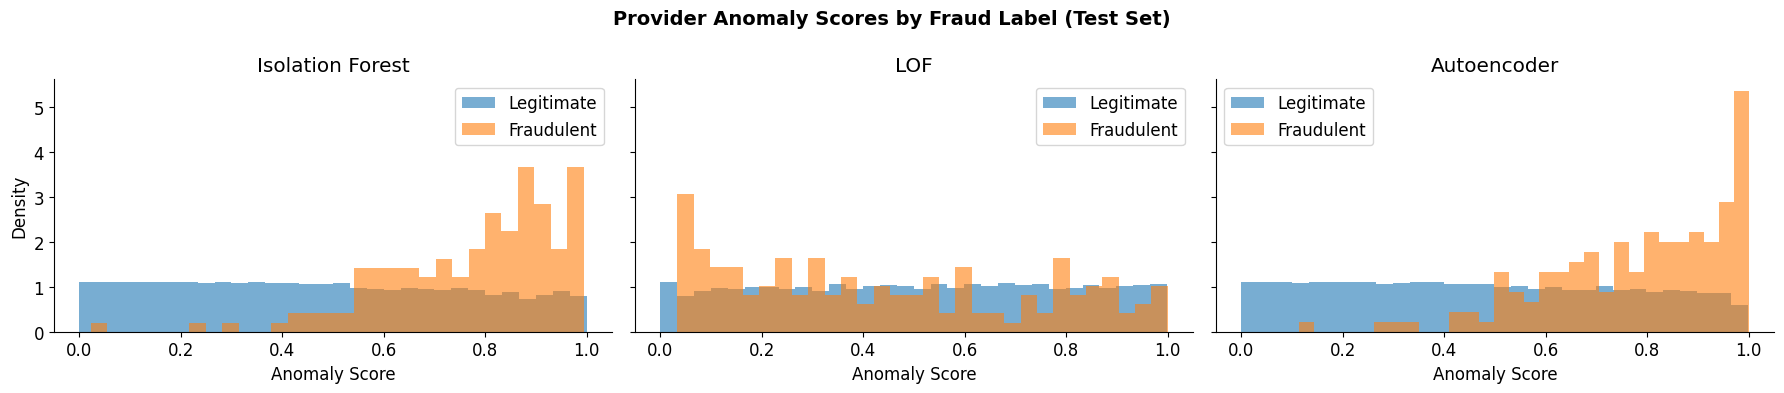

In [44]:
# Visualize score distributions by fraud label (test set)
fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

model_scores = {
    "Isolation Forest": iso_scores_ranked,
    "LOF": lof_scores_ranked,
    "Autoencoder": ae_scores_ranked
}

for ax, (name, scores) in zip(axes, model_scores.items()):
    ax.hist(scores[y_test == 0], bins=30, alpha=0.6, density=True, label="Legitimate")
    ax.hist(scores[y_test == 1], bins=30, alpha=0.6, density=True, label="Fraudulent")
    ax.set_title(name)
    ax.set_xlabel("Anomaly Score")
    ax.legend()

axes[0].set_ylabel("Density")
plt.suptitle("Provider Anomaly Scores by Fraud Label (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

ROC Curves — all models overlaid

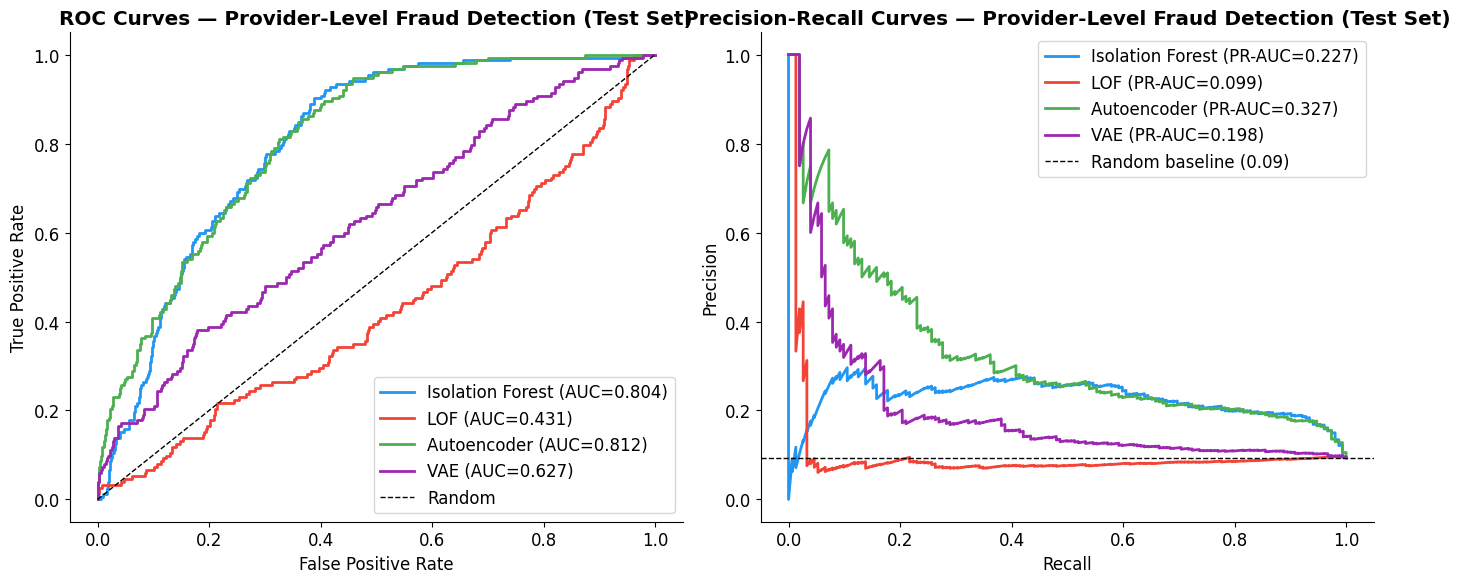

In [45]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

model_scores_dict = {
    'Isolation Forest': iso_scores_ranked,
    'LOF':              lof_scores_ranked,
    'Autoencoder':      ae_scores_ranked,
    'VAE':              vae_scores_ranked
}
colors = ['#2196F3', '#F44336', '#4CAF50', '#9C27B0']

# ROC curves
for (name, scores), color in zip(model_scores_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, scores)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})', color=color, linewidth=2)

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Provider-Level Fraud Detection (Test Set)', fontweight='bold')
axes[0].legend(loc='lower right')

# Precision-Recall curves
for (name, scores), color in zip(model_scores_dict.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, scores)
    pr_auc = auc(rec, prec)
    axes[1].plot(rec, prec, label=f'{name} (PR-AUC={pr_auc:.3f})', color=color, linewidth=2)

baseline = y_test.mean()
axes[1].axhline(baseline, color='k', linestyle='--', linewidth=1,
                label=f'Random baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Provider-Level Fraud Detection (Test Set)', fontweight='bold')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Reconstruction error distribution - Autoencoder anomaly score separated by label

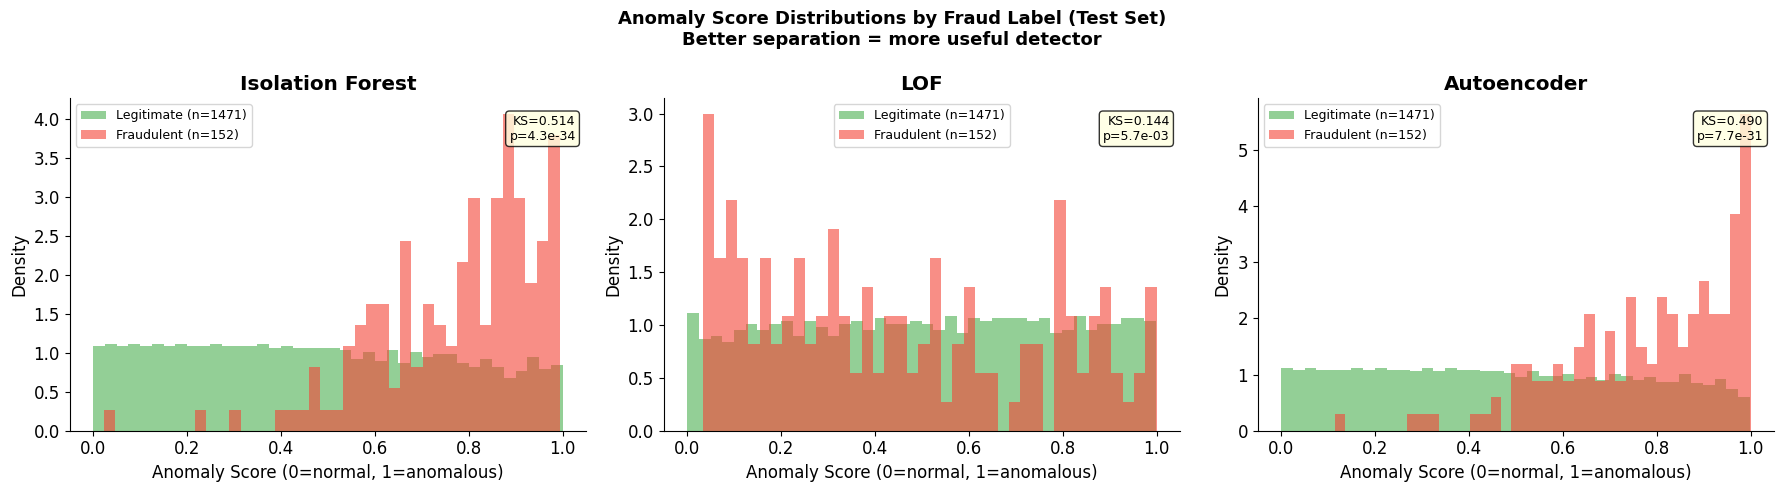

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use only IF, LOF, AE for this comparison (matches the original 3-panel layout)
plot_scores = {
    'Isolation Forest': iso_scores_ranked,
    'LOF':              lof_scores_ranked,
    'Autoencoder':      ae_scores_ranked
}
colors = ['#2196F3', '#F44336', '#4CAF50']

for ax, (name, scores), color in zip(axes, plot_scores.items(), colors):
    legit_scores = scores[y_test == 0]
    fraud_scores = scores[y_test == 1]

    ax.hist(legit_scores, bins=40, alpha=0.6, density=True,
            label=f'Legitimate (n={len(legit_scores)})', color='#4CAF50')
    ax.hist(fraud_scores, bins=40, alpha=0.6, density=True,
            label=f'Fraudulent (n={len(fraud_scores)})', color='#F44336')

    ks_stat, ks_p = stats.ks_2samp(legit_scores, fraud_scores)
    ax.text(0.98, 0.95, f'KS={ks_stat:.3f}\np={ks_p:.1e}',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', alpha=0.8))

    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Anomaly Score (0=normal, 1=anomalous)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

plt.suptitle('Anomaly Score Distributions by Fraud Label (Test Set)\n'
             'Better separation = more useful detector',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('anomaly_score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

Precision @ K sweep - Shows full threshold sensitivity, not just 2 points

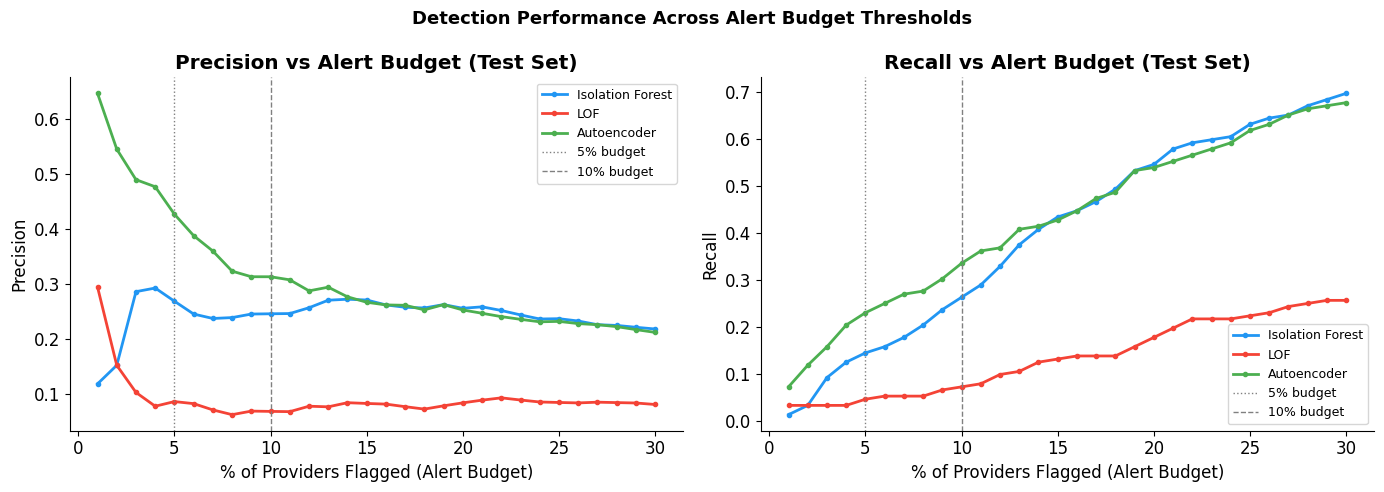

In [47]:
fractions = np.arange(0.01, 0.31, 0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, scores), color in zip(model_scores_dict.items(), colors):
    precisions, recalls, f1s = [], [], []
    for frac in fractions:
        m, _ = evaluate_at_top_fraction(y_test, scores, top_fraction=frac)
        precisions.append(m['precision'])
        recalls.append(m['recall'])
        f1s.append(m['f1'])

    axes[0].plot(fractions * 100, precisions, label=name, color=color, linewidth=2, marker='o', markersize=3)
    axes[1].plot(fractions * 100, recalls,    label=name, color=color, linewidth=2, marker='o', markersize=3)

for ax in axes:
    ax.axvline(5,  color='gray', linestyle=':', linewidth=1, label='5% budget')
    ax.axvline(10, color='gray', linestyle='--', linewidth=1, label='10% budget')
    ax.set_xlabel('% of Providers Flagged (Alert Budget)')
    ax.legend(fontsize=9)

axes[0].set_ylabel('Precision')
axes[0].set_title('Precision vs Alert Budget (Test Set)', fontweight='bold')
axes[1].set_ylabel('Recall')
axes[1].set_title('Recall vs Alert Budget (Test Set)', fontweight='bold')

plt.suptitle('Detection Performance Across Alert Budget Thresholds',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('precision_recall_sweep.png', dpi=150, bbox_inches='tight')
plt.show()

Bootstrap Confidence - Intervals for ROC-AUC

In [48]:
# =========================
# Bootstrap confidence intervals — 500 iterations, 95% CI (test set)
# =========================
from sklearn.utils import resample

def bootstrap_auc(y_true, scores, n_bootstrap=500, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], scores[idx]))
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def bootstrap_pr_auc(y_true, scores, n_bootstrap=500, seed=42):
    rng = np.random.RandomState(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = resample(np.arange(len(y_true)), random_state=rng)
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(average_precision_score(y_true[idx], scores[idx]))
    return np.mean(aucs), np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

print("Bootstrap Results — Test Set (500 iterations, 95% confidence intervals)")
print("=" * 75)
print(f"{'Model':<20} {'ROC-AUC':>25} {'PR-AUC':>25}")
print("-" * 75)

ci_results = []
for name, scores in model_scores_dict.items():
    roc_mean, roc_lo, roc_hi = bootstrap_auc(y_test, scores)
    pr_mean,  pr_lo,  pr_hi  = bootstrap_pr_auc(y_test, scores)
    print(f"{name:<20} {roc_mean:.3f} [{roc_lo:.3f}, {roc_hi:.3f}]   {pr_mean:.3f} [{pr_lo:.3f}, {pr_hi:.3f}]")
    ci_results.append({
        'Model': name,
        'ROC_AUC_mean': roc_mean, 'ROC_AUC_lo': roc_lo, 'ROC_AUC_hi': roc_hi,
        'PR_AUC_mean':  pr_mean,  'PR_AUC_lo':  pr_lo,  'PR_AUC_hi':  pr_hi,
    })

ci_df = pd.DataFrame(ci_results).sort_values('ROC_AUC_mean', ascending=False)
ci_df.to_csv('model_bootstrap_ci_testset.csv', index=False)

print("\nSaved to model_bootstrap_ci_testset.csv")

Bootstrap Results — Test Set (500 iterations, 95% confidence intervals)
Model                                  ROC-AUC                    PR-AUC
---------------------------------------------------------------------------
Isolation Forest     0.804 [0.773, 0.831]   0.234 [0.190, 0.284]
LOF                  0.432 [0.380, 0.476]   0.102 [0.074, 0.134]
Autoencoder          0.812 [0.783, 0.839]   0.332 [0.265, 0.403]
VAE                  0.627 [0.582, 0.671]   0.203 [0.147, 0.260]

Saved to model_bootstrap_ci_testset.csv


## 12. Financial impact analysis

**What we're doing:** Translating model performance into dollars. For each model flagging the top 10% of suspicious providers, we look up how much money those flagged providers actually received. True positives (correctly flagged fraudulent providers) represent recoverable reimbursements. False positives (legitimate providers wrongly flagged) represent investigation costs. We test three investigation cost scenarios: `$500`, `$1,000`, and `$2,000` per provider investigated.

**Goal:** Answer the question that actually matters to a healthcare system: given a fixed investigation budget, which model produces the best financial return?

In [49]:
# =========================
# 15. ROI analysis (test set)
# =========================
# Use idx_test to pull the exact provider rows that were in the test set
provider_eval = provider_agg.iloc[idx_test][["Provider", "FraudLabel", "TotalReimbursed"]].reset_index(drop=True)
provider_eval["IF_pred_10"]  = iso_pred_10
provider_eval["LOF_pred_10"] = lof_pred_10
provider_eval["AE_pred_10"]  = ae_pred_10
provider_eval["VAE_pred_10"] = vae_pred_10

roi_rows = []
for model_name, pred_col in [
    ("Isolation Forest", "IF_pred_10"),
    ("LOF",              "LOF_pred_10"),
    ("Autoencoder",      "AE_pred_10"),
    ("VAE",              "VAE_pred_10"),
]:
    for fp_cost in [500, 1000, 2000]:
        row = financial_impact_table(provider_eval, pred_col, fp_cost=fp_cost)
        row["Model"] = model_name
        row["FalsePositiveCost"] = fp_cost
        roi_rows.append(row)

roi_df = pd.DataFrame(roi_rows)
roi_df = roi_df[
    ["Model", "FalsePositiveCost", "true_positive_providers",
     "false_positive_providers", "recoverable_reimbursement",
     "investigation_cost", "net_roi"]
].sort_values(["FalsePositiveCost", "net_roi"], ascending=[True, False])

print("ROI on TEST SET (30% of providers). Multiply by ~3.33 for full-population estimate.")
display(roi_df)

ROI on TEST SET (30% of providers). Multiply by ~3.33 for full-population estimate.


,Model,FalsePositiveCost,true_positive_providers,false_positive_providers,recoverable_reimbursement,investigation_cost,net_roi
6,Autoencoder,500,51,112,68844110,56000,68788110
0,Isolation Forest,500,40,123,56140710,61500,56079210
9,VAE,500,31,132,49887770,66000,49821770
3,LOF,500,11,152,19545950,76000,19469950
7,Autoencoder,1000,51,112,68844110,112000,68732110
1,Isolation Forest,1000,40,123,56140710,123000,56017710
10,VAE,1000,31,132,49887770,132000,49755770
4,LOF,1000,11,152,19545950,152000,19393950
8,Autoencoder,2000,51,112,68844110,224000,68620110
2,Isolation Forest,2000,40,123,56140710,246000,55894710


**What the results tell us: At `$1,000` per investigation:** the Autoencoder recovers $68.8M in fraudulent reimbursements on the test set at an investigation cost of $112K — a net ROI of $68.7M. Isolation Forest is second at $56.1M recovery / $123K cost / $56.0M net ROI. VAE delivers $49.8M net, LOF $19.5M net. Even at the worst-case $2,000 per investigation, all four models remain massively net-positive because investigation costs are tiny relative to recoverable amounts (under 0.5% in every case). The financial story is dominated almost entirely by how many fraudulent providers you correctly catch, not by how many false positives you generate. Scaled to the full population (× 3.33), the Autoencoder's recoverable amount approaches ~$229M, with Isolation Forest at ~$187M.

## 13. Save artifacts

This makes the notebook reproducible and makes it easy to separate data prep from later reporting.

In [50]:
# =========================
# 16. Save datasets and scores (test set only)
# =========================
provider_scored = provider_agg.iloc[idx_test].copy().reset_index(drop=True)
provider_scored["IF_Score"]            = iso_scores_ranked
provider_scored["LOF_Score"]           = lof_scores_ranked
provider_scored["AE_Score"]            = ae_scores_ranked
provider_scored["VAE_Score"]           = vae_scores_ranked
provider_scored["IF_Pred_10"]          = iso_pred_10
provider_scored["LOF_Pred_10"]         = lof_pred_10
provider_scored["AE_Pred_10"]          = ae_pred_10
provider_scored["VAE_Pred_10"]         = vae_pred_10
provider_scored["IF_Pred_Theoretical"] = iso_pred_theoretical

provider_scored.to_csv("provider_modeling_dataset_testset.csv", index=False)
comparison_05.to_csv("model_comparison_top5_testset.csv", index=False)
comparison_10.to_csv("model_comparison_top10_testset.csv", index=False)
roi_df.to_csv("model_roi_analysis_testset.csv", index=False)

print("Saved:")
print(" - provider_modeling_dataset_testset.csv")
print(" - model_comparison_top5_testset.csv")
print(" - model_comparison_top10_testset.csv")
print(" - model_roi_analysis_testset.csv")

Saved:
 - provider_modeling_dataset_testset.csv
 - model_comparison_top5_testset.csv
 - model_comparison_top10_testset.csv
 - model_roi_analysis_testset.csv


# Summary of Findings

The central finding of this project is that modern anomaly detection methods substantially outperform the classical density-based approach identified in the 2014 baseline paper on a real-world healthcare fraud dataset.

**What worked and why.** The Autoencoder achieved the best overall performance with a ROC-AUC of 0.812 [0.783, 0.839] and a PR-AUC of 0.332 [0.265, 0.403] on the held-out test set. Its strength is its ability to learn a compact, non-linear representation of normal provider behavior from the 3,433 legitimate training providers and use reconstruction failure as the anomaly signal. Isolation Forest is a close second at ROC-AUC 0.804 [0.773, 0.831] and offers a unique advantage: its theoretical threshold from Liu, Ting & Zhou (2008) requires no prior knowledge of the fraud rate, making it the natural choice for cold-start deployment. Both methods make no parametric assumptions about the data distribution and handle the mixed-data problem (40 features spanning billing volumes, diagnosis patterns, physician network structure, demographics, and temporal volatility) cleanly.

**What didn't work and why.** LOF achieved ROC-AUC 0.432, which is worse than random. Its 95% confidence interval sits entirely below 0.5, meaning the result is not noise — LOF actively misranks fraudulent and legitimate providers in this setting. With 40 features, the curse of dimensionality collapses the local density variation that LOF depends on. This directly validates and strengthens the 2014 baseline paper's concern about classical methods on high-dimensional mixed healthcare data: it's not just that they're suboptimal, they can be actively misleading. The VAE underperformed the plain Autoencoder by 0.19 ROC-AUC points. The KL divergence constraint, useful for generative modeling, over-regularizes on this small training set and smooths out exactly the distinctions the model needs to learn.

**Methodological rigor.** Following the professor's feedback, the unsupervised models are trained on a 70% training partition and evaluated on a strictly held-out 30% test partition (1,623 providers, 152 fraudulent), stratified by fraud label and matching the supervised notebook's split exactly. This eliminates the label-leakage pattern of the original evaluation, where the same providers contributed to both training the model and being scored by it. The numerical performance shifted modestly (Isolation Forest dropped from 0.841 to 0.804, Autoencoder rose from 0.802 to 0.812 in this honest evaluation), but the substantive conclusions — modern methods beat classical methods, the Autoencoder is competitive with Isolation Forest, LOF fails on high-dimensional mixed data — are strengthened rather than weakened. The Isolation Forest analysis additionally reports results at the theoretical threshold of s > 0.5, which makes no assumption about the underlying fraud rate, providing a true cold-start evaluation.

**Financial impact.** On the test set, the Autoencoder identifies 51 of 152 fraudulent providers at a 10% alert budget, representing $68.8M in recoverable reimbursements at $112K investigation cost — a net ROI of $68.7M. Scaled to the full population, this represents roughly $229M in recoverable fraudulent reimbursements per modeling cycle. Across all investigation cost scenarios ($500–$2,000 per provider), the dominant factor in net ROI is detection accuracy, not false-positive cost.

**The story versus supervised baselines.** The supervised notebook (with labeled fraud and SMOTE balancing) achieves ROC-AUC in the 0.93–0.95 range. The gap between the best unsupervised model (Autoencoder at 0.812) and the best supervised model is roughly 0.13–0.14 AUC points. This quantifies the value of labeled fraud data: meaningful but not enormous. For a healthcare system deploying fraud detection before any fraud has been confirmed and labeled, an unsupervised approach delivers approximately 85% of the discrimination ceiling on day one, and provides a way to bootstrap the labels needed to eventually train supervised models.